This notebook takes in a list of galaxies and the voids found using $V^2$ (multiple catalogs) and appends to the list of galaxies columns that denote which are void, wall, edge, and outside the survey for each catalog.

In [1]:
from astropy.table import Table
from astropy.io import fits

import numpy as np

import matplotlib.pyplot as plt

import sys
sys.path.insert(1, '/Users/kdouglass/Documents/Research/Voids/code/nb/')
from vflag_v2 import determine_vflag_V2

Incompatible version of OpenGL_accelerate found, need at least (3, 1, 6) found (3, 1, 5)


# Galaxies

In [2]:
gal_filename = '../../../../data/nsa_v1_0_1_VAGC.fits'

hdu = fits.open(gal_filename)
data = Table(hdu[1].data)
hdu.close()

In [3]:
data[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,u_r_err,g_r,g_r_err,NUV_r,NUV_r_err,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,flag3727,t3,Z12logOH,Zerr,N12logNH,NHerr,logNO,NOerr,Ne12logNeH,NeHerr,logNeO,NeOerr,Z_N2O2,vorvol,CMD_class
str19,str27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,str7,float32,int16,uint8,int16,str3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,str8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,str6,str27,str8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
J094651.40-010228.5,09h/m00/J094651.40-010228.5,146.714215072841,-1.0412800233313741,0,72212,37354,-1,-1,-1,15.178774,0.021222278,sdss,0.07,756,1,206,301,136.2967,1095.152,0,0.020687785,29.696056 .. 3267.6895,0.29814342 .. 0.00012172792,1,31.368013 .. 3501.2527,-15.17281 .. -20.302134,223.03555 .. 1102.6129,0.4536473 .. 0.080934174,-0.005893635 .. 0.019576037,0.00017777947 .. 5.1533486e-11,0.00020792194 .. 0.98780394,2.7473723e-05,0.31195974,0.035135116,8898397000.0,215.39407348632812,213.4535369873047,10 .. 12,0.3149959 .. 0.0,233.37904 .. 0.0,0.062215745 .. -0.07950058,0.0006146176 .. -0.1274703,0.8828513 .. 0.7387829,0.2829979 .. -60.97547,18.203371 .. 2264.6604,1.9946122 .. 0.015697604,1.0260131 .. 561.97687,47.3397 .. 0.33574256,0.88909996,14.777527,0.80408496,17.367554,19.554192 .. 3146.785,1.0691423 .. 0.017162137,4.7761517,0.6651653,15.97821,-0.0109440535 .. 0.004525926,0.042470127 .. 0.042621203,0 .. 0,0,36,v2_1_13,0.22341923 .. 258.39,7.2478933,3.4641922,10.453795,5.882104,266,1,51630,146.71420341874853,-1.0412749124036818,0.0,sdss,legacy,good,122,146.71421,-1.0413043,0.80408496,17.367554,1144.0713,0.4582725,7.3913364,3.7061903,10.666219,7.3913364,18.787916 .. 2225.009,1.8480047 .. 0.017611798,5.8557696 .. 3.4004514,11.650886 .. 10.1460905,0.9986329,1.0687045 .. 1.001099,1.0695114 .. 1.0010818,28.532349 .. 2310.4973,0.42499655 .. 0.00024172392,1,28.661283 .. 2337.7668,-15.124495 .. -19.

In [12]:
# Rename columns for VoidFinder functions
data['RA'].name = 'ra'
data['DEC'].name = 'dec'

# $V^2$ classification

In [4]:
V2_directory = '../../../void_catalogs/SDSS/V2/VIDE/'

# V2_gal_filename = '../../../void_catalogs/public/v1.1.0/V2_nsa_v1_0_1_gal.txt'
# galzones_filename = '../../../void_catalogs/public/v1.1.0/V2_VIDE-nsa_v1_0_1_galzones.dat'
# zonevoids_filename = '../../../void_catalogs/public/v1.1.0/V2_VIDE-nsa_v1_0_1_zonevoids.dat'

# V2_gals = Table.read(V2_gal_filename, format='ascii.commented_header')
# galzones = Table.read(galzones_filename, format='ascii.commented_header') 
# zonevoids = Table.read(zonevoids_filename, format='ascii.commented_header')

## Nominal central density cut ($0.2\overline{\rho}$), no minimum void radius

In [5]:
V2_noRmin_filename = V2_directory + 'SDSS_dc0.2_mr0_V2_VIDE_Output.fits'

hdul = fits.open(V2_noRmin_filename)
galzones_noRmin = Table(hdul[4].data)
zonevoids_noRmin = Table(hdul[3].data)
zmax = hdul[0].header['ZLIMU']
Omega_M0 = hdul[0].header['OMEGAM']
h = hdul[0].header['HP']
hdul.close()

total_glx_noRmin = len(galzones_noRmin)

In [6]:
galzones_noRmin[:5]

GAL,TARGET,X,Y,Z,ZONE,DEPTH,EDGE,OUT
int64,int64,float64,float64,float64,int64,int64,int64,int64
0,1,-159.36054286267418,104.96488159962891,-2.5485156533297904,1036,0,1,0
1,3,-295.75752834707146,192.5509670080031,-4.129559482147193,-1,-1,0,1
2,4,-138.80642787227666,90.26771908202177,-1.5743680115813803,1036,0,1,0
3,5,-238.29128139118922,154.963938546414,-3.767348033819445,1036,0,1,0
4,7,-308.0463574790943,201.12066034513953,-5.194227537074168,-1,-1,0,1


In [7]:
zonevoids_noRmin[:5]

ZONE,VOID0,VOID1
int64,int64,int64
0,-1,-1
1,-1,-1
2,-1,-1
3,96,96
4,-1,-1


### Determine and add vflag column to data array

In [13]:
data['vflag_V2_noRmin'] = determine_vflag_V2(data, 
                                             galzones_noRmin, 
                                             zonevoids_noRmin, 
                                             zmax, 
                                             Omega_M0, 
                                             h)

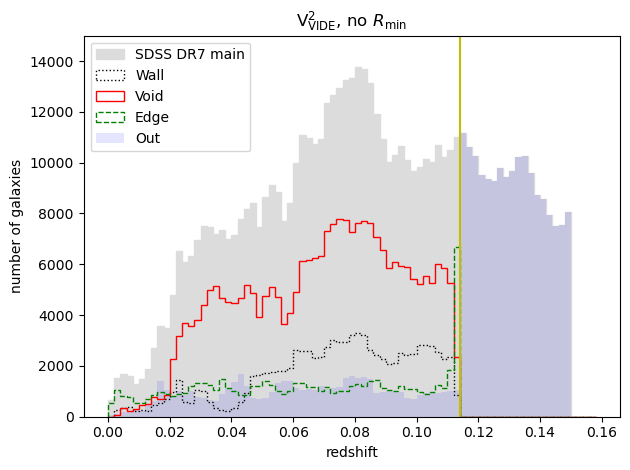

In [17]:
plt.figure(tight_layout=True)

z_bins = np.arange(0,0.16,0.002)

plt.hist(data['Z'], bins=z_bins, color='gainsboro', ec='gainsboro', label='SDSS DR7 main')
plt.hist(data['Z'][data['vflag_V2_noRmin'] == 0], 
         bins=z_bins, histtype='step', linestyle='dotted', color='k', label='Wall')
plt.hist(data['Z'][data['vflag_V2_noRmin'] == 1], 
         bins=z_bins, histtype='step', color='r', label='Void')
plt.hist(data['Z'][data['vflag_V2_noRmin'] == 2], 
         bins=z_bins, histtype='step', color='g', linestyle='dashed', label='Edge')
plt.hist(data['Z'][data['vflag_V2_noRmin'] == 9], 
         bins=z_bins, color='b', alpha=0.1, label='Out')

plt.vlines(0.114, 0, 30000, colors='y')

plt.ylim(0,15000)

plt.xlabel('redshift')
plt.ylabel('number of galaxies')

plt.title(r'V$^2_{\rm VIDE}$, no $R_{\rm min}$')

plt.legend();

## Central density cut of $0.1\overline{\rho}$, $R_{\rm min} = 10$ Mpc/$h$

In [18]:
V2_0p1_filename = V2_directory + 'SDSS_dc0.1_mr10_V2_VIDE_Output.fits'

hdul = fits.open(V2_0p1_filename)
galzones_0p1 = Table(hdul[4].data)
zonevoids_0p1 = Table(hdul[3].data)
# zmax = hdul[0].header['ZLIMU']
# Omega_M0 = hdul[0].header['OMEGAM']
# h = hdul[0].header['HP']
hdul.close()

### Determine and add vflag column to data array

In [19]:
data['vflag_V2_0p1rho'] = determine_vflag_V2(data, 
                                             galzones_0p1, 
                                             zonevoids_0p1, 
                                             zmax, 
                                             Omega_M0, 
                                             h)

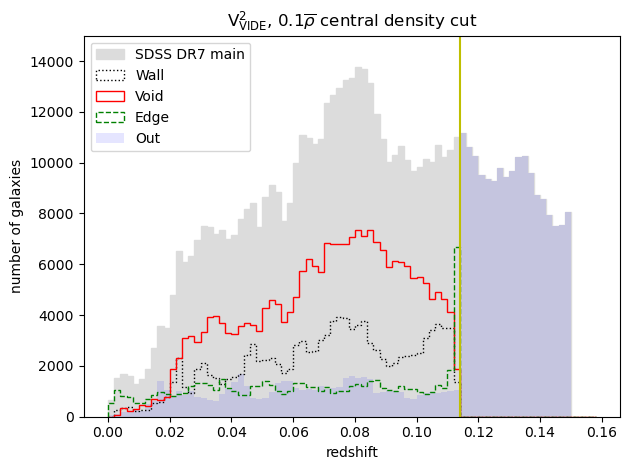

In [21]:
plt.figure(tight_layout=True)

z_bins = np.arange(0,0.16,0.002)

plt.hist(data['Z'], bins=z_bins, color='gainsboro', ec='gainsboro', label='SDSS DR7 main')
plt.hist(data['Z'][data['vflag_V2_0p1rho'] == 0], 
         bins=z_bins, histtype='step', linestyle='dotted', color='k', label='Wall')
plt.hist(data['Z'][data['vflag_V2_0p1rho'] == 1], 
         bins=z_bins, histtype='step', color='r', label='Void')
plt.hist(data['Z'][data['vflag_V2_0p1rho'] == 2], 
         bins=z_bins, histtype='step', color='g', linestyle='dashed', label='Edge')
plt.hist(data['Z'][data['vflag_V2_0p1rho'] == 9], 
         bins=z_bins, color='b', alpha=0.1, label='Out')

plt.vlines(0.114, 0, 30000, colors='y')

plt.ylim(0,15000)

plt.xlabel('redshift')
plt.ylabel('number of galaxies')

plt.title(r'V$^2_{\rm VIDE}$, $0.1\overline{\rho}$ central density cut')

plt.legend();

## Central density cut of $0.3\overline{\rho}$, $R_{\rm min} = 10$ Mpc/$h$

In [22]:
V2_0p3_filename = V2_directory + 'SDSS_dc0.3_mr10_V2_VIDE_Output.fits'

hdul = fits.open(V2_0p3_filename)
galzones_0p3 = Table(hdul[4].data)
zonevoids_0p3 = Table(hdul[3].data)
# zmax = hdul[0].header['ZLIMU']
# Omega_M0 = hdul[0].header['OMEGAM']
# h = hdul[0].header['HP']
hdul.close()

### Determine and add vflag column to data array

In [24]:
data['vflag_V2_0p3rho'] = determine_vflag_V2(data, 
                                             galzones_0p3, 
                                             zonevoids_0p3, 
                                             zmax, 
                                             Omega_M0, 
                                             h)

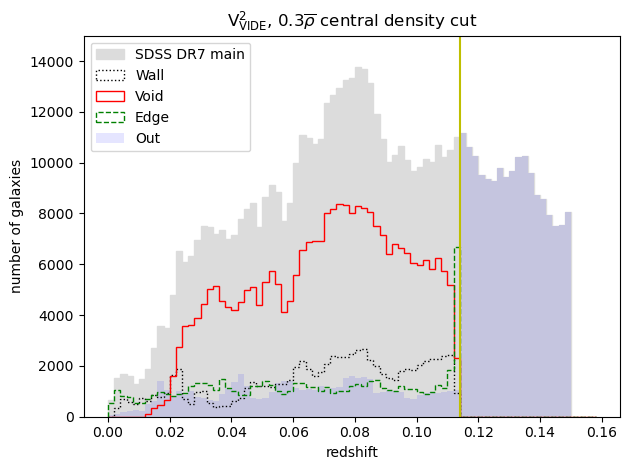

In [25]:
plt.figure(tight_layout=True)

z_bins = np.arange(0,0.16,0.002)

plt.hist(data['Z'], bins=z_bins, color='gainsboro', ec='gainsboro', label='SDSS DR7 main')
plt.hist(data['Z'][data['vflag_V2_0p3rho'] == 0], 
         bins=z_bins, histtype='step', linestyle='dotted', color='k', label='Wall')
plt.hist(data['Z'][data['vflag_V2_0p3rho'] == 1], 
         bins=z_bins, histtype='step', color='r', label='Void')
plt.hist(data['Z'][data['vflag_V2_0p3rho'] == 2], 
         bins=z_bins, histtype='step', color='g', linestyle='dashed', label='Edge')
plt.hist(data['Z'][data['vflag_V2_0p3rho'] == 9], 
         bins=z_bins, color='b', alpha=0.1, label='Out')

plt.vlines(0.114, 0, 30000, colors='y')

plt.ylim(0,15000)

plt.xlabel('redshift')
plt.ylabel('number of galaxies')

plt.title(r'V$^2_{\rm VIDE}$, $0.3\overline{\rho}$ central density cut')

plt.legend();

# Save results to file

In [26]:
data.write('../../../../data/nsa_v1_0_1_VAGC_vflag-V2_sys.fits')